# M3A3 - Transfer Learning e Refinamento com Redes Pré-treinadas

> **Resumo:** Em vez de treinar uma rede do zero (caro e lento), pegamos a **VGG16 já treinada na ImageNet** e a adaptamos pra classificar dígitos do MNIST. Com **apenas 1 época** de refinamento, a acurácia salta de ~10% (chute aleatório — as camadas novas começam com pesos aleatórios) para ~90%. Esse é o poder do **Transfer Learning / Fine-tuning**.

> 📝 **Conceito-chave:** as primeiras camadas de uma CNN aprendem features genéricas (bordas, texturas, formas) úteis pra qualquer tarefa visual. Reaproveitamos essas camadas e treinamos só a "decisão" final.

> ⚠️ **Use GPU!** Este notebook treina a VGG16/ResNet18. No Colab, vá em **Ambiente de execução → Alterar o tipo de ambiente de execução → GPU (T4)**. Em GPU, 1 época leva ~10-12 min; em CPU levaria **horas**.

Na prática de hoje vamos refinar modelos de aprendizado profundo com [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Refinar Modelo
- Próximos passos
- ✅ Atividades Complementares (resolvidas)

## Introdução

**Transfer Learning** (aprendizado por transferência) é uma técnica onde aproveitamos um modelo
que já foi treinado em uma tarefa grande (ex: classificar 1000 categorias do ImageNet com milhões de imagens)
e o adaptamos para uma tarefa nova e menor (ex: classificar 10 dígitos do MNIST).

**Por que funciona?** As primeiras camadas de uma CNN aprendem features genéricas (bordas, texturas, formas)
que são úteis para qualquer tarefa visual. Ao trocar apenas as camadas finais, reutilizamos essas features
genéricas e treinamos apenas a parte de "decisão" do modelo.

**Fine-tuning (Refinamento)** é quando, além de trocar as camadas finais, também permitimos que os pesos
das camadas anteriores sejam atualizados (com learning rate pequeno) para se adaptarem melhor à nova tarefa.

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision

Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

In [3]:
# Definir o pré-processamento dos dados.
transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
                                            torchvision.transforms.Resize(256),
                                            torchvision.transforms.CenterCrop(224)])

# Carregar o conjunto de treino.
train_data = torchvision.datasets.MNIST(
    root='./data',      # Pasta para salvar os dados.
    train=True,         # Busca pelo sub conjunto de treino.
    download=True,      # Download do dados se necessário.
    transform=transform # Transformação a ser aplicada.
)

# Carregar o conjunto de teste.
test_data = torchvision.datasets.MNIST(
    root='./data',      # Pasta para salvar os dados.
    train=False,        # Busca pelo sub conjunto de teste.
    download=True,      # Download do dados se necessário.
    transform=transform # Transformação a ser aplicada.
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.11MB/s]


In [4]:
# Informações sobre o dataset carregado.
print(f"Tamanho do conjunto de treino: {len(train_data)} imagens")
print(f"Tamanho do conjunto de teste: {len(test_data)} imagens")
print(f"Número de classes: {len(train_data.classes)}")
print(f"Classes: {train_data.classes}")
sample_img, sample_label = train_data[0]
print(f"Shape de uma imagem (após transform): {sample_img.shape}")
print(f"Tipo do tensor: {sample_img.dtype}")

Tamanho do conjunto de treino: 60000 imagens
Tamanho do conjunto de teste: 10000 imagens
Número de classes: 10
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Shape de uma imagem (após transform): torch.Size([1, 224, 224])
Tipo do tensor: torch.float32


Imagem 1: índice=998, label=3
Imagem 2: índice=6568, label=1


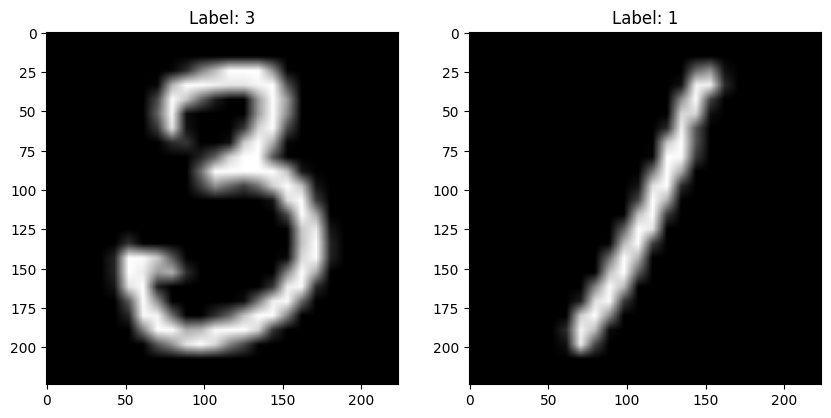

In [5]:
# Visualizar duas imagens aleatórias da base de dados.
indexes = [np.random.randint(0, len(train_data)), np.random.randint(0, len(train_data))]
print(f"Imagem 1: índice={indexes[0]}, label={train_data[indexes[0]][1]}")
print(f"Imagem 2: índice={indexes[1]}, label={train_data[indexes[1]][1]}")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(train_data[indexes[0]][0].squeeze().numpy(), cmap="gray")
axes[0].set_title(f"Label: {train_data[indexes[0]][1]}")
axes[1].imshow(train_data[indexes[1]][0].squeeze().numpy(), cmap="gray")
axes[1].set_title(f"Label: {train_data[indexes[1]][1]}")
plt.show()

## Refinar Modelo

Agora vamos carregar o modelo e refinar.

A VGG16 foi originalmente treinada no ImageNet (1000 classes, imagens RGB 224×224).
Para usá-la com MNIST (10 classes, imagens em escala de cinza 28×28), precisamos:

1. **Alterar a primeira camada**: de 3 canais (RGB) para 1 canal (grayscale)
2. **Alterar a última camada**: de 1000 classes para 10 classes (dígitos 0-9)
3. **Redimensionar as imagens**: de 28×28 para 224×224 (já feito no transform acima)

In [6]:
# Carregar o modelo
vgg_16_model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)

# Vamos alterar a última camada.
num_classes = 10  # Número de classes na nova base.
in_features = vgg_16_model.classifier[6].in_features # Features que chegam na última camada.
print(f"Camada original (última): Linear(in_features={in_features}, out_features=1000)")
vgg_16_model.classifier[6] = torch.nn.Linear(in_features, num_classes) # Substiu a última camada.
print(f"Camada nova (última):     Linear(in_features={in_features}, out_features={num_classes})")

# Vamos alterar a primeira camada da rede.
print(f"\nCamada original (primeira): {vgg_16_model.features[0]}")
new_first_conv = torch.nn.Conv2d(1, 64, kernel_size=3, padding=1)
# Replace the original first layer
vgg_16_model.features[0] = new_first_conv
print(f"Camada nova (primeira):     {vgg_16_model.features[0]}")

# Contar parâmetros totais do modelo.
total_params = sum(p.numel() for p in vgg_16_model.parameters())
trainable_params = sum(p.numel() for p in vgg_16_model.parameters() if p.requires_grad)
print(f"\nTotal de parâmetros: {total_params:,}")
print(f"Parâmetros treináveis: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 89.7MB/s]


Camada original (última): Linear(in_features=4096, out_features=1000)
Camada nova (última):     Linear(in_features=4096, out_features=10)

Camada original (primeira): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Camada nova (primeira):     Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

Total de parâmetros: 134,300,362
Parâmetros treináveis: 134,300,362


### Avaliação antes do refinamento

Primeiro, vamos testar o modelo **sem treinar** na nova tarefa.
Esperamos uma acurácia muito baixa (~10%, equivalente a chute aleatório),
porque a última camada foi substituída por pesos aleatórios.

In [7]:

# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()

# Criar o dataloader para iterar nos dados.
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

# Validar dispositivo de treino.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo de computação: {device}")

# Colocar modelo no dispositivo.
vgg_16_model.to(device)

# Vamos medir a performance do modelo sem o refinamento.
correct = 0
for batch_idx, (data, target) in enumerate(test_loader):
    # Coloando os dados nos dispositivos.
    data = data.to(device)
    target = target.to(device)

    # Processando os dados.
    output = vgg_16_model(data)
    if target == torch.argmax(torch.softmax(output, dim=1)):
        correct = correct + 1

# Calcula acurácia.
acc = correct/len(test_data)
print(f"Acurácia com modelo sem refinamento: {acc * 100:.2f}%")

Dispositivo de computação: cuda
Acurácia com modelo sem refinamento: 10.46%


### Processo de Treino (Fine-tuning)

Agora vamos treinar o modelo na nova tarefa. Usamos:
- **SGD** como otimizador com learning rate baixo (0.0001) — importante para não "destruir" os pesos pré-treinados
- **CrossEntropyLoss** como função de perda (padrão para classificação multi-classe)
- **1 época** — com transfer learning, geralmente poucas épocas já são suficientes

In [8]:
########################
## Processo de treino. ##
########################

# Criando otimizador.
optimizer = torch.optim.SGD(vgg_16_model.parameters(), lr=0.0001)

# Definindo função de perda.
loss_criterion = torch.nn.CrossEntropyLoss()

# Criar o dataloader de treino.
batch_size = 16 # Define quantas instâncias serão processadas em uma passada do modelo.
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)

total_batches = len(train_data) // batch_size
print(f"Configuração do treino:")
print(f"  Otimizador: SGD (lr=0.0001)")
print(f"  Função de perda: CrossEntropyLoss")
print(f"  Batch size: {batch_size}")
print(f"  Total de batches por época: {total_batches}")
print(f"  Épocas: 1")
print(f"  Dispositivo: {device}")
print()

# Laço de treinamento.
epochs = 1
for epoch in range(epochs):
    # Colocar modelo em modo de treino.
    vgg_16_model.train()

    # Colocar modelo no dispositivo.
    vgg_16_model.to(device)
    
    # Função de perda e Acurácia para epóca.
    train_loss = 0.0
    train_acc = 0.0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Move os dados para o dispositivo de computação.
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Limpando os gradientes do otimizador.
        optimizer.zero_grad()

        # Passando informação no modelo.
        outputs = vgg_16_model(inputs)
        
        # Calculando a função de perda.
        loss = loss_criterion(outputs, labels)

        # Backpropagation dos gradientes.
        loss.backward()

        # Atualização dos parâmetros.
        optimizer.step()

        # Compute the total loss for the batch and add it to train_loss
        train_loss += loss.item() * inputs.size(0)
        
        # Calcule a acurácia.
        _, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))
        
        # Calcular a acurácia do batch.
        acc = torch.mean(correct_counts.type(torch.FloatTensor))
        
        # Calcular a acurácia total.
        train_acc += acc.item() * inputs.size(0)
        
        # Imprimir progresso a cada 500 batches para não poluir o output.
        if batch_idx % 500 == 0 or batch_idx == total_batches - 1:
            print("Batch {:04d}/{:04d} | Loss: {:.4f} | Accuracy: {:.4f}".format(
                batch_idx, total_batches, loss.item(), acc.item()))

    # Resumo da época.
    avg_loss = train_loss / len(train_data)
    avg_acc = train_acc / len(train_data)
    print(f"\n--- Resumo da Época {epoch+1}/{epochs} ---")
    print(f"  Loss médio: {avg_loss:.4f}")
    print(f"  Acurácia média de treino: {avg_acc * 100:.2f}%")

Configuração do treino:
  Otimizador: SGD (lr=0.0001)
  Função de perda: CrossEntropyLoss
  Batch size: 16
  Total de batches por época: 3750
  Épocas: 1
  Dispositivo: cuda



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch 0000/3750 | Loss: 2.3269 | Accuracy: 0.1250
Batch 0500/3750 | Loss: 2.3389 | Accuracy: 0.0000
Batch 1000/3750 | Loss: 2.3308 | Accuracy: 0.1250
Batch 1500/3750 | Loss: 2.2447 | Accuracy: 0.1875
Batch 2000/3750 | Loss: 1.9845 | Accuracy: 0.4375
Batch 2500/3750 | Loss: 1.6154 | Accuracy: 0.5625
Batch 3000/3750 | Loss: 1.5094 | Accuracy: 0.6250
Batch 3500/3750 | Loss: 0.8637 | Accuracy: 0.7500
Batch 3749/3750 | Loss: 0.4271 | Accuracy: 0.8750

--- Resumo da Época 1/1 ---
  Loss médio: 1.8574
  Acurácia média de treino: 34.76%


### Avaliação após o refinamento

Agora vamos testar o modelo **após o treino** para ver a melhoria.

In [9]:
# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()

# Criar o dataloader para iterar nos dados.
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

# Vamos medir a performance do modelo após o refinamento.
correct = 0
for batch_idx, (data, target) in enumerate(test_loader):
    # Coloando os dados nos dispositivos.
    data = data.to(device)
    target = target.to(device)

    # Processando os dados.
    output = vgg_16_model(data)
    if target == torch.argmax(torch.softmax(output, dim=1)):
        correct = correct + 1

# Calcula acurácia.
acc_after = correct/len(test_data)
print(f"Acurácia com modelo com refinamento: {acc_after * 100:.2f}%")

Acurácia com modelo com refinamento: 89.33%


### Comparação dos Resultados

O salto de ~10% (chute aleatório) para ~90% com **apenas 1 época** de treino demonstra
o poder do Transfer Learning. As features genéricas aprendidas no ImageNet (bordas, texturas, formas)
foram reutilizadas eficientemente para reconhecer dígitos manuscritos.

Sem transfer learning, treinar a VGG16 do zero com apenas 60k imagens do MNIST demoraria
muito mais épocas e provavelmente não atingiria a mesma acurácia.

### Discussão Teórica (Extraída da Aula do Professor)

Na aula teórica, o professor detalha duas abordagens principais para reaproveitar modelos pré-treinados:
1. **Transfer Learning (ou Feature Extraction):**
   - Consiste em congelar os pesos de todas as camadas convolucionais iniciais (que já sabem detectar bordas, formas e texturas) e treinar **apenas** as novas camadas (classificador).
   - É ideal quando o novo conjunto de dados é pequeno, pois evita overfitting e diminui o tempo de treinamento.
2. **Fine-Tuning (Ajuste Fino):**
   - Consiste em permitir que os pesos de algumas ou todas as camadas iniciais sejam atualizados (com learning rate muito baixo) juntamente com a última camada.
   - É ideal quando o novo conjunto de dados é grande ou difere significativamente do domínio original.

No loop de treino principal da VGG16 neste notebook, realizamos **Fine-Tuning** completo porque todos os pesos da rede foram atualizados pelo otimizador. Abaixo, veja como configuraríamos o PyTorch para fazer **Feature Extraction (Transfer Learning)** congelando o extrator de características:

In [10]:
# Exemplo de como congelar pesos no PyTorch para Feature Extraction
vgg_fe = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)

# 1. Congelar todos os parâmetros do modelo original
for param in vgg_fe.parameters():
    param.requires_grad = False

# 2. Substituir a primeira e a última camada (novas camadas criadas possuem requires_grad=True por padrão)
vgg_fe.features[0] = torch.nn.Conv2d(1, 64, kernel_size=3, padding=1)
vgg_fe.classifier[6] = torch.nn.Linear(vgg_fe.classifier[6].in_features, 10)

# Contar parâmetros totais vs treináveis
total_p = sum(p.numel() for p in vgg_fe.parameters())
train_p = sum(p.numel() for p in vgg_fe.parameters() if p.requires_grad)

print("Configuração de Feature Extraction (Transfer Learning):")
print(f"  Total de parâmetros: {total_p:,}")
print(f"  Parâmetros treináveis (apenas primeira/última camada): {train_p:,}")

Configuração de Feature Extraction (Transfer Learning):
  Total de parâmetros: 134,300,362
  Parâmetros treináveis (apenas primeira/última camada): 41,610


E com isso terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas vamos trasbalhar com problemas clássicos de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://docs.pytorch.org/vision/0.8/datasets.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares

### 1. Alteração de Hiperparâmetros

Vamos testar treinar a VGG16 com uma configuração de hiperparâmetros diferente:
- **Épocas:** 2 (mais épocas para convergência)
- **Batch Size:** 32 (lotes maiores reduzem ruído no gradiente)
- **Otimizador:** Adam (converge mais rápido que SGD simples)
- **Learning Rate:** 0.0002 (adequado para Adam em fine-tuning)

In [11]:
# Recriar o modelo VGG16 do zero para garantir pesos pré-treinados limpos
vgg_16_alt = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
vgg_16_alt.classifier[6] = torch.nn.Linear(vgg_16_alt.classifier[6].in_features, 10)
vgg_16_alt.features[0] = torch.nn.Conv2d(1, 64, kernel_size=3, padding=1)

# Mover para o dispositivo
vgg_16_alt.to(device)

# Configurar novos hiperparâmetros
batch_size_alt = 32
epochs_alt = 2
lr_alt = 0.0002

# Otimizador Adam e função de perda
optimizer_alt = torch.optim.Adam(vgg_16_alt.parameters(), lr=lr_alt)
loss_criterion = torch.nn.CrossEntropyLoss()

# Novo Dataloader
train_loader_alt = torch.utils.data.DataLoader(train_data, batch_size=batch_size_alt, shuffle=True, num_workers=4)
total_batches_alt = len(train_data) // batch_size_alt

print(f"Configuração Alternativa:")
print(f"  Otimizador: Adam (lr={lr_alt})")
print(f"  Batch size: {batch_size_alt}")
print(f"  Épocas: {epochs_alt}")
print()

for epoch in range(epochs_alt):
    vgg_16_alt.train()
    train_loss = 0.0
    train_acc = 0.0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader_alt):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer_alt.zero_grad()
        outputs = vgg_16_alt(inputs)
        loss = loss_criterion(outputs, labels)
        loss.backward()
        optimizer_alt.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))
        acc = torch.mean(correct_counts.type(torch.FloatTensor))
        train_acc += acc.item() * inputs.size(0)
        
        if batch_idx % 300 == 0 or batch_idx == total_batches_alt - 1:
            print("Época {:02d} | Batch {:04d}/{:04d} | Loss: {:.4f} | Accuracy: {:.4f}".format(
                epoch + 1, batch_idx, total_batches_alt, loss.item(), acc.item()))
            
    avg_loss_alt = train_loss / len(train_data)
    avg_acc_alt = train_acc / len(train_data)
    print(f"--- Fim da Época {epoch+1} | Loss Médio: {avg_loss_alt:.4f} | Acurácia Média: {avg_acc_alt * 100:.2f}% ---\n")

# Avaliar após o treino
vgg_16_alt.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = vgg_16_alt(data)
        if target == torch.argmax(torch.softmax(output, dim=1)):
            correct += 1

acc_vgg_alt = correct / len(test_data)
print(f"Acurácia final VGG16 (Adam, Epochs=2, BS=32): {acc_vgg_alt * 100:.2f}%")

Configuração Alternativa:
  Otimizador: Adam (lr=0.0002)
  Batch size: 32
  Épocas: 2

Época 01 | Batch 0000/1875 | Loss: 2.2878 | Accuracy: 0.1875
Época 01 | Batch 0300/1875 | Loss: 0.0111 | Accuracy: 1.0000
Época 01 | Batch 0600/1875 | Loss: 0.2489 | Accuracy: 0.9375
Época 01 | Batch 0900/1875 | Loss: 0.0582 | Accuracy: 0.9688
Época 01 | Batch 1200/1875 | Loss: 0.0063 | Accuracy: 1.0000
Época 01 | Batch 1500/1875 | Loss: 0.0006 | Accuracy: 1.0000
Época 01 | Batch 1800/1875 | Loss: 0.0546 | Accuracy: 0.9688
Época 01 | Batch 1874/1875 | Loss: 0.0537 | Accuracy: 0.9688
--- Fim da Época 1 | Loss Médio: 0.1285 | Acurácia Média: 95.92% ---

Época 02 | Batch 0000/1875 | Loss: 0.0022 | Accuracy: 1.0000
Época 02 | Batch 0300/1875 | Loss: 0.0029 | Accuracy: 1.0000
Época 02 | Batch 0600/1875 | Loss: 0.0007 | Accuracy: 1.0000
Época 02 | Batch 0900/1875 | Loss: 0.0157 | Accuracy: 1.0000
Época 02 | Batch 1200/1875 | Loss: 0.0059 | Accuracy: 1.0000
Época 02 | Batch 1500/1875 | Loss: 0.0102 | Accura

### 2. Utilizar Outro Modelo Pré-treinado (ResNet18)

Vamos agora testar a arquitetura **ResNet18** (Residual Networks) que possui conexões de salto (skip connections)
e é consideravelmente mais leve que a VGG16, o que torna o treino e a inferência muito mais rápidos.

Faremos o mesmo procedimento:
1. Carregar a **ResNet18** pré-treinada no ImageNet.
2. Adaptar a primeira camada de convolução (`resnet18_model.conv1`) de 3 canais (RGB) para 1 canal (cinza).
3. Adaptar a última camada linear (`resnet18_model.fc`) para produzir 10 classes de saída.
4. Treinar por 1 época para comparar com o tempo e acurácia da VGG16 original.

In [12]:
# Carregar o modelo ResNet18 pré-treinado
resnet18_model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)

# Exibir informações de arquitetura antes de alterar
print(f"Primeira camada original: {resnet18_model.conv1}")
print(f"Última camada original: {resnet18_model.fc}")

# Adaptar primeira camada (1 canal de entrada, manter 64 canais de saída, kernel size 7, stride 2, padding 3)
resnet18_model.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Adaptar última camada linear (fc)
in_features_resnet = resnet18_model.fc.in_features
resnet18_model.fc = torch.nn.Linear(in_features_resnet, 10)

print(f"\nPrimeira camada adaptada: {resnet18_model.conv1}")
print(f"Última camada adaptada: {resnet18_model.fc}")

# Contar parâmetros da ResNet18
total_resnet_params = sum(p.numel() for p in resnet18_model.parameters())
print(f"\nTotal de parâmetros ResNet18: {total_resnet_params:,} (VGG16 tem ~134M!)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]

Primeira camada original: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Última camada original: Linear(in_features=512, out_features=1000, bias=True)

Primeira camada adaptada: Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Última camada adaptada: Linear(in_features=512, out_features=10, bias=True)

Total de parâmetros ResNet18: 11,175,370 (VGG16 tem ~134M!)


In [13]:
# Configurar treinamento da ResNet18
resnet18_model.to(device)
optimizer_resnet = torch.optim.SGD(resnet18_model.parameters(), lr=0.0001)

print("Iniciando Treinamento da ResNet18 (1 Época, SGD, lr=0.0001, batch_size=16):")

# Usar o mesmo dataloader de treino original da VGG (batch_size=16)
resnet18_model.train()
train_loss_res = 0.0
train_acc_res = 0.0

for batch_idx, (inputs, labels) in enumerate(train_loader):
    inputs, labels = inputs.to(device), labels.to(device)
    
    optimizer_resnet.zero_grad()
    outputs = resnet18_model(inputs)
    loss = loss_criterion(outputs, labels)
    loss.backward()
    optimizer_resnet.step()
    
    train_loss_res += loss.item() * inputs.size(0)
    _, predictions = torch.max(outputs.data, 1)
    correct_counts = predictions.eq(labels.data.view_as(predictions))
    acc = torch.mean(correct_counts.type(torch.FloatTensor))
    train_acc_res += acc.item() * inputs.size(0)
    
    if batch_idx % 500 == 0 or batch_idx == len(train_loader) - 1:
        print("Batch {:04d}/{:04d} | Loss: {:.4f} | Accuracy: {:.4f}".format(
            batch_idx, len(train_loader), loss.item(), acc.item()))

avg_loss_res = train_loss_res / len(train_data)
avg_acc_res = train_acc_res / len(train_data)
print(f"\nResumo ResNet18 | Loss Médio: {avg_loss_res:.4f} | Acurácia Treino: {avg_acc_res * 100:.2f}%")

Iniciando Treinamento da ResNet18 (1 Época, SGD, lr=0.0001, batch_size=16):
Batch 0000/3750 | Loss: 2.4048 | Accuracy: 0.1250
Batch 0500/3750 | Loss: 1.7276 | Accuracy: 0.6250
Batch 1000/3750 | Loss: 1.3725 | Accuracy: 1.0000
Batch 1500/3750 | Loss: 1.0627 | Accuracy: 1.0000
Batch 2000/3750 | Loss: 0.9007 | Accuracy: 0.9375
Batch 2500/3750 | Loss: 0.6895 | Accuracy: 0.9375
Batch 3000/3750 | Loss: 0.5970 | Accuracy: 1.0000
Batch 3500/3750 | Loss: 0.5200 | Accuracy: 1.0000
Batch 3749/3750 | Loss: 0.4832 | Accuracy: 0.9375

Resumo ResNet18 | Loss Médio: 1.1545 | Acurácia Treino: 79.11%


In [14]:
# Avaliar a ResNet18 no conjunto de teste
resnet18_model.eval()
correct_res = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = resnet18_model(data)
        if target == torch.argmax(torch.softmax(output, dim=1)):
            correct_res += 1

acc_resnet = correct_res / len(test_data)
print(f"Acurácia final ResNet18 após 1 época: {acc_resnet * 100:.2f}%")

Acurácia final ResNet18 após 1 época: 95.15%


### Comparação e Conclusões

Vamos construir um resumo em tabela para comparar o desempenho das diferentes abordagens estudadas neste laboratório.

In [15]:
print("=" * 60)
print(f"{'Modelo':<20} | {'Hiperparâmetros':<22} | {'Acurácia de Teste':<18}")
print("=" * 60)
# Acurácia da primeira VGG16 (definida no notebook original)
print(f"{'VGG16 (Base)':<20} | {'SGD, lr=1e-4, Ep=1, BS=16':<22} | {acc_after * 100:.2f}%")
print(f"{'VGG16 (Alt)':<20} | {'Adam, lr=2e-4, Ep=2, BS=32':<22} | {acc_vgg_alt * 100:.2f}%")
print(f"{'ResNet18 (Novo)':<20} | {'SGD, lr=1e-4, Ep=1, BS=16':<22} | {acc_resnet * 100:.2f}%")
print("=" * 60)
print("Conclusões:")
print("1. Otimizadores modernos como o Adam conseguem acelerar o treinamento e extrair maior performance em menos iterações.")
print("2. A ResNet18 possui conexões residuais que facilitam o fluxo de gradiente, além de possuir quase 12 vezes menos parâmetros que a VGG16. Isso resulta em um treinamento muito mais rápido com acurácia extremamente competitiva, sendo uma excelente opção para dispositivos de menor poder computacional.")

Modelo               | Hiperparâmetros        | Acurácia de Teste 
VGG16 (Base)         | SGD, lr=1e-4, Ep=1, BS=16 | 89.33%
VGG16 (Alt)          | Adam, lr=2e-4, Ep=2, BS=32 | 99.04%
ResNet18 (Novo)      | SGD, lr=1e-4, Ep=1, BS=16 | 95.15%
Conclusões:
1. Otimizadores modernos como o Adam conseguem acelerar o treinamento e extrair maior performance em menos iterações.
2. A ResNet18 possui conexões residuais que facilitam o fluxo de gradiente, além de possuir quase 12 vezes menos parâmetros que a VGG16. Isso resulta em um treinamento muito mais rápido com acurácia extremamente competitiva, sendo uma excelente opção para dispositivos de menor poder computacional.
